# Cascade Prompt-Injection Detector — Figure Gallery

Every figure in the write-up, regenerated in one place from the frozen score
files. The code is lifted verbatim from `scripts/make_figures.py`,
`scripts/make_figure_failure_overlap.py` and `scripts/make_figure_theta_sweep.py`
so a figure here cannot differ from the one in the paper.

**Run order matters.** Execute section 0 top to bottom once, then any figure
section in any order.

**Payload hygiene (CLAUDE.md).** Nothing here reads or prints dataset text — only
`id` / `label` / `channel`, `len(text)`, and per-row scores. Do not add cells that
display raw rows from `data/`.

### Differences from the scripts

| Script | Notebook | Why |
|---|---|---|
| `mpl.use("Agg")` | removed | Agg suppresses inline display |
| `ROOT = Path(__file__)...` | hardcoded path | no `__file__` in a notebook |
| `argparse` in `main()` | plain function arguments | nothing to parse |
| `fig.savefig(...)` | `plt.show()` | display instead of write |
| `style()` (×3 scripts) | `style()`, `style_overlap()`, `style_sweep()` | three different functions shared one name |

`INK`, `INK_2`, `INK_MUTED`, `BLUE`, `ORANGE`, `RED` and `FPR_TARGET` are defined
identically in all three scripts, so the later definitions are harmless.

## 0. Setup

### 0.1 Imports and paths

In [29]:
import argparse
import json
import sys
from pathlib import Path

import matplotlib as mpl

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve  # noqa: E402

ROOT = Path("/Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid")   # hardcoded: no __file__ in a notebook
for _p in (ROOT, ROOT / "src"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

from scripts.eval_cascade import _cascade_point, _read_labels, _read_logits  # noqa: E402
from src.evaluation.metrics import detection_rate_at_fpr, ece  # noqa: E402

from types import SimpleNamespace

%matplotlib inline
FPR_TARGET = 0.01
print('ROOT', ROOT, '| exists:', ROOT.exists())

ROOT /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid | exists: True


### 0.2 Palette and entity registry

Colour is assigned per **entity**, so a detector keeps its hue in every figure. The categorical order is CVD-validated; each series also carries a distinct linestyle and marker so identity survives greyscale printing.

In [30]:
INK = "#0b0b0b"
INK_2 = "#52514e"
INK_MUTED = "#8a8880"
GRID = "#d8d7d2"
SURFACE = "#ffffff"

# CVD-validated categorical order (all-pairs PASS for the 4 slots used per panel).
BLUE, ORANGE, AQUA, VIOLET, YELLOW, RED = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#eda100", "#e34948"

# entity -> (label, colour, linestyle, marker)
ENT = {
    "mistral7b":    ("M2 (Mistral-7B, Stage 2)",      BLUE,   "-",  "o"),
    "qwen":         ("Qwen-2.5-1.5B (Stage 1)",       ORANGE, "--", "s"),
    "llama":        ("Llama-3.2-1B (Stage 1)",        AQUA,   "-.", "^"),
    "granite":      ("Granite-Guardian-2B (Stage 1)", VIOLET, ":",  "D"),
    "protectai":    ("ProtectAI DeBERTa-v3 (v2)",     RED,    "--", "v"),
    "promptguard2": ("PromptGuard 2 (86M)",           YELLOW, "-.", "P"),
    "datasentinel": ("DataSentinel-7B (verdict)",     INK_2,  "",   "X"),
    "cascade_llama": ("Cascade: Llama-1B -> M2",      AQUA,   "-",  "^"),
    "cascade_qwen":  ("Cascade: Qwen-1.5B -> M2",     ORANGE, "-",  "s"),
}
# compact labels for the narrow single-column variant
SHORT = {"mistral7b": "M2 (Mistral-7B)", "qwen": "Qwen-2.5-1.5B", "llama": "Llama-3.2-1B",
         "granite": "Granite-Guardian-2B", "protectai": "ProtectAI DeBERTa",
         "promptguard2": "PromptGuard 2", "datasentinel": "DataSentinel-7B",
         "cascade_llama": "Cascade: Llama-1B", "cascade_qwen": "Cascade: Qwen-1.5B"}


def elabel(k: str, width: str) -> str:
    return SHORT[k] if width == "single" else ENT[k][0]


CHANNEL_COLOR = {"direct": BLUE, "document": ORANGE, "tool": AQUA}
SPLIT_COLOR = {"in_dist": BLUE, "ood": ORANGE}

OURS = ["mistral7b", "qwen", "llama", "granite"]
OFFSHELF = ["protectai", "promptguard2"]

WIDTHS = {"double": 7.0, "single": 3.4}

### 0.3 Styling and drawing helpers

In [31]:
def style(width: str) -> None:
    base = 8.5 if width == "double" else 7.2
    mpl.rcParams.update({
        "figure.dpi": 120, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": base, "axes.labelsize": base, "axes.titlesize": base,
        "xtick.labelsize": base - 0.8, "ytick.labelsize": base - 0.8,
        "legend.fontsize": base - 1.3, "legend.frameon": False,
        "legend.handlelength": 2.0, "legend.labelspacing": 0.28,
        "legend.borderpad": 0.2, "legend.handletextpad": 0.5,
        "axes.linewidth": 0.6, "axes.edgecolor": INK_2, "axes.labelcolor": INK,
        "text.color": INK, "xtick.color": INK_2, "ytick.color": INK_2,
        "xtick.major.width": 0.6, "ytick.major.width": 0.6,
        "xtick.major.size": 2.5, "ytick.major.size": 2.5,
        "axes.spines.top": False, "axes.spines.right": False,
        "lines.linewidth": 1.5, "lines.markersize": 4.0,
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
        "axes.grid": False,
    })


def grid(ax, axis="both"):
    ax.set_axisbelow(True)
    ax.grid(True, axis=axis, color=GRID, linewidth=0.5, linestyle="-")


def panels(width: str, n: int, h_double: float, h_single: float):
    """Facet layout: side-by-side at double width, stacked at single width."""
    if width == "double":
        fig, axes = plt.subplots(1, n, figsize=(WIDTHS["double"], h_double))
    else:
        fig, axes = plt.subplots(n, 1, figsize=(WIDTHS["single"], h_single * n))
    return fig, (np.atleast_1d(axes).ravel().tolist())


def plabel(ax, txt):
    ax.set_title(txt, loc="left", fontsize=mpl.rcParams["axes.titlesize"], color=INK, pad=4)


def thin(x, y, n=1200):
    """Thin a step curve for compact vector output, keeping endpoints/extremes."""
    if len(x) <= n:
        return x, y
    idx = np.unique(np.concatenate([[0, len(x) - 1], np.linspace(0, len(x) - 1, n).astype(int)]))
    return x[idx], y[idx]


def barlabel(ax, rects, fmt="{:.2f}", dy=0.012, na_mask=None):
    for i, r in enumerate(rects):
        h = r.get_height()
        if na_mask is not None and na_mask[i]:
            ax.text(r.get_x() + r.get_width() / 2, dy, "n/a", ha="center", va="bottom",
                    fontsize=mpl.rcParams["legend.fontsize"] - 0.3, color=INK_MUTED, rotation=90)
            continue
        ax.text(r.get_x() + r.get_width() / 2, h + dy, fmt.format(h), ha="center", va="bottom",
                fontsize=mpl.rcParams["legend.fontsize"] - 0.3, color=INK_2)

### 0.4 Score loading

`load()` reads the frozen per-sample logit files through the same code paths that produced the reported numbers (`detection_rate_at_fpr`, `_cascade_point`).

In [32]:
STAGE1_DIRS = {"llama": "results_kaggle/stage1/llama3.2-1b",
               "qwen": "results_kaggle/stage1/qwen2.5-1.5b",
               "granite": "results_kaggle/stage1/granite-guardian-2b"}


STAGE2_DIR = "results/stage2/mistral-7b-v0.1"


EVAL_SPLIT = "data/eval_proposal/eval.jsonl"


CAL_SPLIT = "data/train_proposal/cal.jsonl"


VAL_SPLIT = "data/train_proposal/val.jsonl"


CASCADES = {"cascade_llama": ("llama", "results/analysis/cascade_llama3/cascade_summary.json"),
            "cascade_qwen": ("qwen", "results/analysis/cascade_qwen2/cascade_summary.json")}


def _meta(path: Path):
    """id / label / channel / len(text) only -- never the text itself."""
    ids, lab, ch, tlen = [], [], [], []
    with path.open() as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            ids.append(r["id"]); lab.append(int(r["label"]))
            ch.append(r.get("channel") or "")
            tlen.append(len(r.get("text") or ""))
    return ids, np.asarray(lab, int), np.asarray(ch, object), np.asarray(tlen, int)


def load() -> dict:
    d: dict = {}
    ids, y, ch, tlen = _meta(ROOT / EVAL_SPLIT)
    d["ids"], d["y"], d["ch"], d["tlen"] = ids, y, ch, tlen

    # generative detectors: p_safe -> injection score
    d["psafe"], d["score"] = {}, {}
    for k, sub in list(STAGE1_DIRS.items()) + [("mistral7b", STAGE2_DIR)]:
        _, _, ps = _read_logits(ROOT / sub / "eval_logits.jsonl")
        if len(ps) != len(y):
            raise SystemExit(f"ROW MISMATCH {sub}/eval_logits={len(ps)} vs eval={len(y)}")
        d["psafe"][k] = ps
        d["score"][k] = 1.0 - ps

    # encoder baselines: per-row score, id-order checked
    for k, sub in [("promptguard2", "results/baselines/predictions/promptguard2_86m.jsonl"),
                   ("protectai", "results/baselines/predictions/protectai_deberta_v2.jsonl")]:
        rows = [json.loads(l) for l in (ROOT / sub).open() if l.strip()]
        if [r["id"] for r in rows] != ids:
            rows = sorted(rows, key=lambda r: ids.index(r["id"]))
        d["score"][k] = np.asarray([r["score"] for r in rows], float)

    # DataSentinel-7B: verdict only (score is null) -> one operating point
    ds = {json.loads(l)["id"]: json.loads(l) for l in (ROOT / "results/predictions/datasentinel_7b.jsonl").open() if l.strip()}
    d["ds_pred"] = np.asarray([int(ds[i]["pred"]) for i in ids], int)

    # cal / val (calibration + generalisation-gap panels)
    d["cal"] = {"y": _read_labels(ROOT / CAL_SPLIT)}
    d["val"] = {"y": _read_labels(ROOT / VAL_SPLIT)}
    for split, sub in (("cal", "cal_logits"), ("val", "val_logits")):
        for k, sd in list(STAGE1_DIRS.items()) + [("mistral7b", STAGE2_DIR)]:
            p = ROOT / sd / f"{sub}.jsonl"
            if p.exists():
                lb, li, ps = _read_logits(p)
                if len(ps) == len(d[split]["y"]):
                    d[split][k] = {"psafe": ps, "score": 1.0 - ps, "logp": (lb, li)}
    lb, li, _ = _read_logits(ROOT / STAGE2_DIR / "eval_logits.jsonl")
    d["eval_logp"] = {"mistral7b": (lb, li)}
    for k, sd in STAGE1_DIRS.items():
        lb, li, _ = _read_logits(ROOT / sd / "eval_logits.jsonl")
        d["eval_logp"][k] = (lb, li)

    d["summaries"] = {k: json.loads((ROOT / p).read_text()) for k, (_, p) in CASCADES.items()}
    d["latency"] = json.loads((ROOT / "results/analysis/latency_measured.json").read_text())
    d["latency_bf16"] = json.loads((ROOT / "results/analysis/latency_measured_bf16stage1.json").read_text())
    d["stage1_sel"] = json.loads((ROOT / "results/metrics/stage1_selection.json").read_text())
    return d


def dr_at(y, s, target=FPR_TARGET):
    r = detection_rate_at_fpr(y, s, (target,))[str(target)]
    return r["dr"], r["threshold"], r["achieved_fpr"]


def cascade_preds(D, key):
    """Final cascade decision per row at the frozen (cal-selected) operating point."""
    s1_key, _ = CASCADES[key]
    summ = D["summaries"][key]
    th_safe = summ["headline_cal_frozen"]["theta_safe"]
    s1_ps, s2 = D["psafe"][s1_key], D["score"]["mistral7b"]
    pt = _cascade_point(s1_ps, s2, D["y"], th_safe, FPR_TARGET)
    esc = s1_ps < th_safe
    pred = np.zeros(len(D["y"]), int)
    if pt["theta2"] is not None:
        pred[esc & (s2 >= pt["theta2"])] = 1
    return pred, pt


def channel_recall(y, ch, pred):
    out = {}
    for c in ("direct", "document", "tool"):
        m = (y == 1) & (ch == c)
        out[c] = float(pred[m].mean()) if m.sum() else float("nan")
    out["overall"] = float(pred[y == 1].mean())
    return out


def recall_by_channel_at_1pct(y, ch, s):
    _, thr, _ = dr_at(y, s)
    return channel_recall(y, ch, (np.asarray(s) >= thr).astype(int))

### 0.5 Load the scores once

This is the slow cell (reads every logit file). Everything after it is fast.

In [33]:
D = load()
print(f"eval n={len(D['y'])}  attacks={int((D['y'] == 1).sum())}  benign={int((D['y'] == 0).sum())}")

eval n=25747  attacks=7113  benign=18634


### 0.6 Figure width

`'double'` is the full-text-width variant used in the paper; `'single'` is the narrow column variant with abbreviated labels. Change this and re-run any figure cell.

In [34]:
WIDTH = "double"   # or "single"

## 1. ROC — every detector

Full ROC for all single-stage detectors on the evaluation split. The operating region that matters is the far left, which is why the next figure exists.

In [35]:
def fig_roc(D, width):
    fig, ax = panels(width, 2, 3.05, 2.85)
    data = {}
    for k in D["score"]:
        fpr, tpr, _ = roc_curve(D["y"], D["score"][k])
        data[k] = {"auroc": float(roc_auc_score(D["y"], D["score"][k]))}
        D.setdefault("_roc", {})[k] = (fpr, tpr)
    groups = [(0, OURS, "(a) Models fine-tuned in this work"),
              (1, ["mistral7b"] + OFFSHELF, "(b) Off-the-shelf detectors")]
    for i, keys, title in groups:
        a = ax[i]
        a.plot([0, 1], [0, 1], color=INK_MUTED, lw=0.7, ls=(0, (2, 2)), zorder=1)
        a.text(0.60, 0.53, "chance", color=INK_MUTED, rotation=38, fontsize=mpl.rcParams["legend.fontsize"] - 0.5)
        for k in keys:
            _, col, ls, mk = ENT[k]; lab = elabel(k, width)
            fpr, tpr = thin(*D["_roc"][k])
            ref = (i == 1 and k == "mistral7b")
            a.plot(fpr, tpr, color=col, ls=(0, (5, 2)) if ref else ls, lw=1.2 if ref else 1.5,
                   label=f"{lab} — AUROC {data[k]['auroc']:.3f}", zorder=3)
            dr, thr, afpr = dr_at(D["y"], D["score"][k])
            a.plot([afpr], [dr], marker=mk, color=col, ms=5.0, mec=SURFACE, mew=0.8, ls="none", zorder=4)
            data[k]["dr_at_1pct_fpr"] = float(dr)
        if i == 1:
            y1 = float(D["ds_pred"][D["y"] == 1].mean()); x1 = float(D["ds_pred"][D["y"] == 0].mean())
            _, col, _, mk = ENT["datasentinel"]; lab = elabel("datasentinel", width)
            a.plot([x1], [y1], marker=mk, color=col, ms=6.5, ls="none", zorder=5,
                   label=f"{lab} — FPR {x1:.2f}")
            a.annotate(f"flags {x1:.0%} of benign", xy=(x1, y1), xytext=(0.26, 0.56), color=INK_2,
                       fontsize=mpl.rcParams["legend.fontsize"] - 0.3, ha="left",
                       arrowprops=dict(arrowstyle="-", lw=0.6, color=INK_MUTED))
            data["datasentinel"] = {"tpr": y1, "fpr": x1}
        a.set_xlim(0, 1); a.set_ylim(0, 1.02)
        a.set_xlabel("False positive rate"); a.set_ylabel("Detection rate (TPR)")
        grid(a)
        plabel(a, title)
        a.legend(loc="lower right", markerscale=0.9)
    fig.tight_layout(pad=0.4)
    return fig, {"note": "ROC on the 25,747-row OOD eval; marker = DR at 1% FPR", "detectors": data}

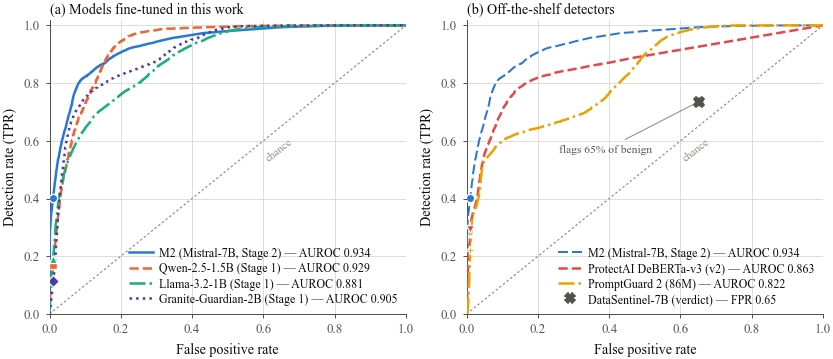

In [36]:
style(WIDTH)
fig, data = fig_roc(D, WIDTH)
plt.show()

### What the figure says

| Detector | AUROC | DR at 1% FPR |
|---|---|---|
| Mistral-7B (M2, fine-tuned) | 0.934 | 0.402 |
| Qwen2.5-1.5B | 0.929 | 0.171 |
| Granite-Guardian-2B | 0.905 | 0.113 |
| Llama3.2-1B | 0.881 | 0.189 |
| ProtectAI DeBERTa | 0.863 | 0.293 |
| PromptGuard 2 | 0.822 | 0.221 |
| DataSentinel-7B | *no curve* | TPR 0.735 at FPR 0.651 |

**The two columns rank the detectors differently, and the right-hand one is the one
that matters.** Qwen scores a higher AUROC than Llama (0.929 against 0.881) but
catches fewer attacks at the threshold anyone would actually deploy (0.171 against
0.189). Granite ranks third by AUROC and last by detection. AUROC averages a
detector's behaviour across every threshold, including the thresholds where it
flags half of all benign traffic — nobody runs a guard there. Section 2 zooms into
the region that is deployable.

**The 7B guard buys 0.005 AUROC and 2.3× the detection.** Almost all of the value
of the larger model sits in the far-left corner of this plot, which is exactly the
part AUROC compresses away.

**DataSentinel is a point, not a curve,** because it returns a decision rather than
a score. It flags 65% of benign inputs, which is 65× over a 1% budget.

## 2. ROC at low FPR

The same curves restricted to the deployable false-positive region. All DR@1%FPR numbers in the paper are read off this.

In [37]:
def fig_roc_lowfpr(D, width):
    fig, ax = panels(width, 2, 3.05, 2.85)
    data = {}
    groups = [(0, OURS, "(a) Models fine-tuned in this work"),
              (1, ["mistral7b"] + OFFSHELF, "(b) Off-the-shelf detectors")]
    for i, keys, title in groups:
        a = ax[i]
        a.axvline(FPR_TARGET, color=INK_MUTED, lw=0.7, ls=(0, (2, 2)), zorder=1)
        a.text(FPR_TARGET * 1.2, 0.62, "1% FPR", color=INK_2, fontsize=mpl.rcParams["legend.fontsize"] - 0.3)
        for k in keys:
            _, col, ls, mk = ENT[k]; lab = elabel(k, width)
            fpr, tpr, _ = roc_curve(D["y"], D["score"][k])
            m = fpr > 0
            fx, ty = thin(fpr[m], tpr[m])
            ref = (i == 1 and k == "mistral7b")
            dr, _, afpr = dr_at(D["y"], D["score"][k])
            a.plot(fx, ty, color=col, ls=(0, (5, 2)) if ref else ls, lw=1.2 if ref else 1.5,
                   label=f"{lab} — DR {dr:.3f}", zorder=3)
            a.plot([afpr], [dr], marker=mk, color=col, ms=5.0, mec=SURFACE, mew=0.8, ls="none", zorder=4)
            data[k] = {"dr_at_1pct_fpr": float(dr), "achieved_fpr": float(afpr)}
        a.set_xscale("log"); a.set_xlim(1e-4, 1.0); a.set_ylim(0, 1.02)
        a.set_xlabel("False positive rate (log)"); a.set_ylabel("Detection rate (TPR)")
        grid(a); plabel(a, title)
        a.legend(loc="upper left", markerscale=0.9)
    fig.tight_layout(pad=0.4)
    return fig, {"note": "low-FPR region; legend reports DR at the 1% FPR operating point", "detectors": data}

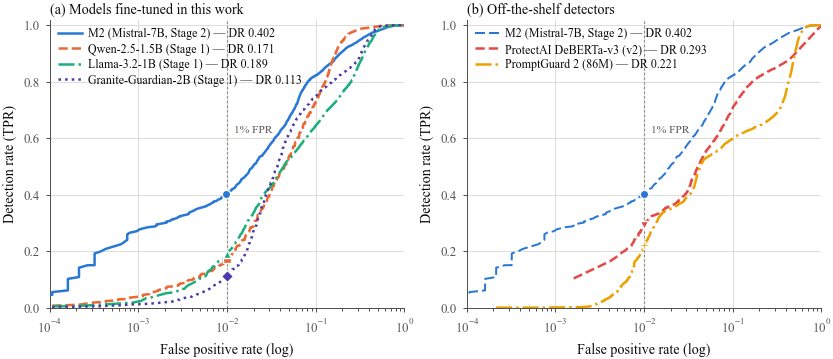

In [38]:
style(WIDTH)
fig, data = fig_roc_lowfpr(D, WIDTH)
plt.show()

### What the figure says

Detection at a 1% false-positive budget, with the false-positive rate each detector
actually achieved (all land within 0.0099–0.0100, so the comparison is fair):

| Detector | DR at 1% FPR | achieved FPR |
|---|---|---|
| Mistral-7B (M2) | 0.402 | 0.0099 |
| ProtectAI DeBERTa | 0.293 | 0.0100 |
| PromptGuard 2 | 0.221 | 0.0100 |
| Llama3.2-1B | 0.189 | 0.0100 |
| Qwen2.5-1.5B | 0.171 | 0.0100 |
| Granite-Guardian-2B | 0.113 | 0.0099 |

**The best detector on this benchmark misses three attacks out of five.** A 7B model
fine-tuned on prompt injection, evaluated on attack corpora it was not trained on,
catches 40%.

**Size does not order this table.** ProtectAI is a 184M-parameter DeBERTa and beats
every 1–2B LLM guard here. What separates the rows is which corpora each detector
saw in training, not capacity — section 5 makes that concrete.

**Caveat.** Every threshold in this notebook is chosen on the evaluation split's own benign scores, so each detection rate is the best that detector could do if you already knew the deployment traffic. Section 8 shows what happens when you do not: the threshold that gives 1% false positives on the calibration split gives 57.9% on the evaluation split. Treat every number above as an upper bound
on deployed behaviour.

## 3. Precision–recall

PR curves, which are the honest view under heavy class imbalance (18,634 benign against 7,113 attacks).

In [39]:
def fig_pr(D, width):
    fig, ax = panels(width, 2, 3.05, 2.85)
    prev = float((D["y"] == 1).mean())
    data = {"prevalence": prev}
    groups = [(0, OURS, "(a) Models fine-tuned in this work"),
              (1, ["mistral7b"] + OFFSHELF, "(b) Off-the-shelf detectors")]
    for i, keys, title in groups:
        a = ax[i]
        a.axhline(prev, color=INK_MUTED, lw=0.7, ls=(0, (2, 2)), zorder=1)
        a.text(0.02, prev + 0.02, f"prevalence {prev:.2f}", color=INK_2,
               fontsize=mpl.rcParams["legend.fontsize"] - 0.3)
        for k in keys:
            _, col, ls, mk = ENT[k]; lab = elabel(k, width)
            pr, rc, _ = precision_recall_curve(D["y"], D["score"][k])
            ap = float(average_precision_score(D["y"], D["score"][k]))
            rx, py = thin(rc, pr)
            ref = (i == 1 and k == "mistral7b")
            a.plot(rx, py, color=col, ls=(0, (5, 2)) if ref else ls, lw=1.2 if ref else 1.5,
                   label=f"{lab} — AP {ap:.3f}", zorder=3)
            data.setdefault("detectors", {})[k] = {"average_precision": ap}
        if i == 1:
            yy = D["y"]; p = D["ds_pred"]
            tp = int(((p == 1) & (yy == 1)).sum()); fp = int(((p == 1) & (yy == 0)).sum())
            prec, rec = tp / (tp + fp), tp / int((yy == 1).sum())
            _, col, _, mk = ENT["datasentinel"]; lab = elabel("datasentinel", width)
            a.plot([rec], [prec], marker=mk, color=col, ms=6.5, ls="none", zorder=5,
                   label=f"{lab} — P {prec:.2f}")
            data["detectors"]["datasentinel"] = {"precision": prec, "recall": rec}
        a.set_xlim(0, 1); a.set_ylim(0, 1.02)
        a.set_xlabel("Recall"); a.set_ylabel("Precision")
        grid(a); plabel(a, title)
        a.legend(loc="lower left", markerscale=0.9)
    fig.tight_layout(pad=0.4)
    return fig, data

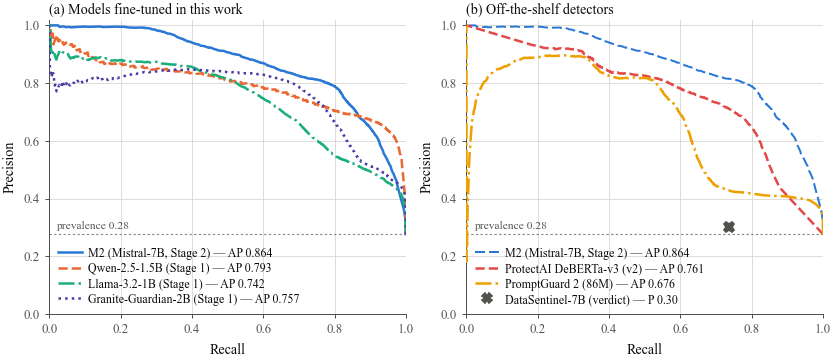

In [40]:
style(WIDTH)
fig, data = fig_pr(D, WIDTH)
plt.show()

### What the figure says

Attacks are 27.6% of the evaluation split, so a detector that guesses gets an average
precision of 0.276. That is the line to beat.

| Detector | Average precision |
|---|---|
| Mistral-7B (M2) | 0.864 |
| Qwen2.5-1.5B | 0.793 |
| ProtectAI DeBERTa | 0.761 |
| Granite-Guardian-2B | 0.757 |
| Llama3.2-1B | 0.742 |
| PromptGuard 2 | 0.676 |
| *base rate* | *0.276* |

**The ranking changes again.** Qwen is second by average precision and fifth by
detection at 1% FPR. Average precision integrates over all recall levels, including
recall levels reached only by flagging most of the traffic. Three summary statistics
of the same scores produce three different leaderboards, which is the argument for
fixing an operating point and reporting there.

**DataSentinel's single point is the clearest read.** It reaches 73.5% recall at 30.1%
precision — 2.5 points above the base rate of 27.6%. Nearly everything it flags is
benign.

## 4. Generalisation gap

In-distribution against out-of-distribution detection for every detector. The **gap**, not the absolute level, is the result: in-distribution numbers carry almost no information about out-of-distribution behaviour.

In [41]:
def fig_generalization_gap(D, width):
    sel = D["stage1_sel"]["rows"]
    ind_val, ood = {}, {}
    for k, name in (("llama", "llama3.2-1b"), ("qwen", "qwen2.5-1.5b"), ("granite", "granite-guardian-2b")):
        ind_val[k] = sel[name]["val"]["dr_at_1pct_fpr"]; ood[k] = sel[name]["eval"]["dr_at_1pct_fpr"]
    ind_val["mistral7b"] = dr_at(D["val"]["y"], D["val"]["mistral7b"]["score"])[0]
    ood["mistral7b"] = dr_at(D["y"], D["score"]["mistral7b"])[0]
    # vendor-reported in-distribution figures (model cards); ProtectAI reports F1 only.
    ind_val["promptguard2"], ind_val["protectai"] = 0.975, float("nan")
    for k in ("promptguard2", "protectai"):
        ood[k] = dr_at(D["y"], D["score"][k])[0]

    order = ["promptguard2", "protectai", "granite", "llama", "qwen", "mistral7b"]
    short = {"promptguard2": "PromptGuard 2\n(86M)", "protectai": "ProtectAI\nDeBERTa-v3",
             "granite": "Granite\nGuardian-2B", "llama": "Llama-3.2\n-1B",
             "qwen": "Qwen-2.5\n-1.5B", "mistral7b": "M2 Mistral-7B\n(Stage 2)"}
    fig, ax = panels(width, 1, 3.0, 3.2)
    a = ax[0]
    x = np.arange(len(order)); w = 0.38
    v_in = np.array([ind_val[k] for k in order], float)
    v_oo = np.array([ood[k] for k in order], float)
    na = np.isnan(v_in)
    r1 = a.bar(x - w / 2, np.nan_to_num(v_in), w, color=SPLIT_COLOR["in_dist"], edgecolor=SURFACE,
               linewidth=0.6, label="In-distribution (val split / vendor-reported)")
    r2 = a.bar(x + w / 2, v_oo, w, color=SPLIT_COLOR["ood"], edgecolor=SURFACE, linewidth=0.6,
               label="Our OOD eval (25,747 rows)")
    barlabel(a, r1, na_mask=na); barlabel(a, r2)
    a.set_xticks(x); a.set_xticklabels([short[k] for k in order])
    a.set_ylim(0, 1.12); a.set_ylabel("Detection rate @ 1% FPR")
    a.set_xlabel("")
    grid(a, axis="y")
    a.legend(loc="upper center", ncol=1 if width == "single" else 2, bbox_to_anchor=(0.5, 1.16))
    fig.tight_layout(pad=0.4)
    fig.text(0.005, -0.015, "ProtectAI reports F1 = 0.95 on its own eval set, not DR@1% FPR.",
             ha="left", va="top", color=INK_MUTED, fontsize=mpl.rcParams["legend.fontsize"] - 0.5)
    return fig, {"in_distribution": {k: (None if np.isnan(ind_val[k]) else ind_val[k]) for k in order},
                 "ood_eval": {k: ood[k] for k in order},
                 "note": "PromptGuard 2 in-distribution value is Meta's reported 97.5% recall@1%FPR"}

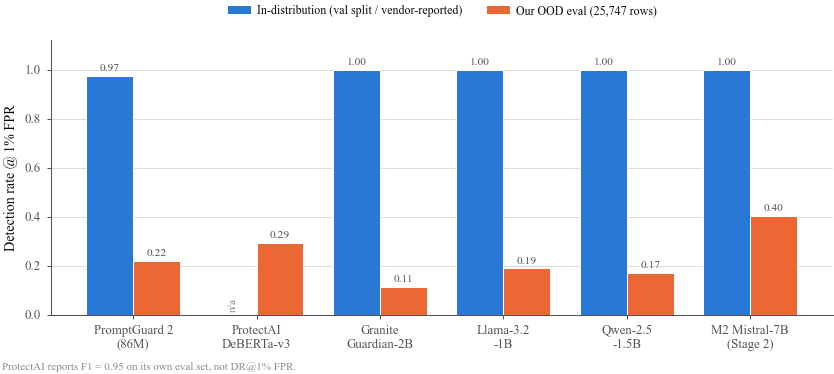

In [42]:
style(WIDTH)
fig, data = fig_generalization_gap(D, WIDTH)
plt.show()

### What the figure says

| Detector | In-distribution | Out-of-distribution | Gap |
|---|---|---|---|
| Granite-Guardian-2B | 1.000 | 0.113 | −0.887 |
| Qwen2.5-1.5B | 1.000 | 0.171 | −0.829 |
| Llama3.2-1B | 0.999 | 0.189 | −0.811 |
| PromptGuard 2 | 0.975 | 0.221 | −0.754 |
| Mistral-7B (M2) | 1.000 | 0.402 | −0.598 |

**The ranking inverts.** Granite is tied for best in-distribution and is the worst
out of distribution. Four of the five detectors are within 0.025 of perfect on
material drawn from their own training distribution, and they spread across a range
of 0.29 once the corpus changes. Knowing a guard's in-distribution recall tells you
essentially nothing about how it will behave on an attack corpus it has not seen.

**Why the numbers are this extreme.** In-distribution here means held-out rows from
the same generator that produced the training rows. Attack corpora are templated, so
a held-out row shares surface vocabulary with rows the model memorised. The model can
reach 1.000 by learning the template.

**Caveat.** The in-distribution column is not comparable *across* rows — each value
comes from that detector's own test set, and PromptGuard 2's is Meta's published
recall at 1% FPR rather than a number measured here. The comparison that holds is
the gap *within* a row.

## 5. Detection by channel

Detection rate split by delivery channel. Channel and source corpus are 1:1 on this benchmark, so channel effects are also corpus effects — read this alongside the payload-overlap audit.

In [43]:
def fig_channel_dr(D, width):
    rows = {}
    for k in ("promptguard2", "protectai", "mistral7b"):
        rows[k] = recall_by_channel_at_1pct(D["y"], D["ch"], D["score"][k])
    for k in CASCADES:
        pred, pt = cascade_preds(D, k)
        rows[k] = channel_recall(D["y"], D["ch"], pred)
        rows[k]["_achieved_fpr"] = pt["e2e_fpr"]
    order = ["promptguard2", "protectai", "mistral7b", "cascade_llama", "cascade_qwen"]
    short = {"promptguard2": "PromptGuard 2", "protectai": "ProtectAI", "mistral7b": "M2 (Stage 2)",
             "cascade_llama": "Cascade\nLlama-1B", "cascade_qwen": "Cascade\nQwen-1.5B"}
    fig, ax = panels(width, 1, 3.0, 3.2)
    a = ax[0]
    x = np.arange(len(order)); w = 0.21
    for j, c in enumerate(("direct", "document", "tool")):
        v = np.array([rows[k][c] for k in order], float)
        r = a.bar(x + (j - 1.5) * w, v, w, color=CHANNEL_COLOR[c], edgecolor=SURFACE, linewidth=0.6,
                  label=f"{c} injection")
        barlabel(a, r, fmt="{:.2f}")
    ov = np.array([rows[k]["overall"] for k in order], float)
    r = a.bar(x + 1.5 * w, ov, w, color=INK_MUTED, edgecolor=SURFACE, linewidth=0.6,
              hatch="///", label="all channels (aggregate)")
    barlabel(a, r, fmt="{:.2f}")
    a.set_xticks(x); a.set_xticklabels([short[k] for k in order])
    a.set_ylim(0, 1.10); a.set_ylabel("Detection rate @ 1% FPR")
    grid(a, axis="y")
    a.legend(loc="upper center", ncol=2 if width == "single" else 4, bbox_to_anchor=(0.5, 1.17))
    fig.tight_layout(pad=0.4)
    return fig, {"per_channel_recall_at_1pct_fpr": rows,
                 "n_attacks_by_channel": {c: int(((D["y"] == 1) & (D["ch"] == c)).sum())
                                          for c in ("direct", "document", "tool")}}

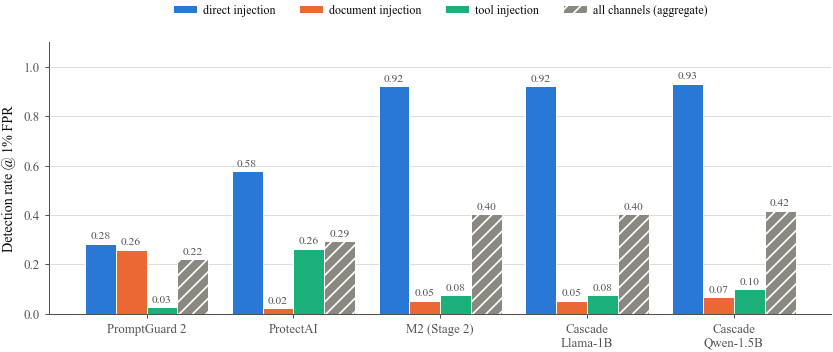

In [44]:
style(WIDTH)
fig, data = fig_channel_dr(D, WIDTH)
plt.show()

### What the figure says

Detection at 1% FPR, split by how the injection reaches the model:

| Detector | direct (n=2,830) | document (n=2,819) | tool (n=1,464) | overall |
|---|---|---|---|---|
| Mistral-7B (M2) | 0.922 | 0.054 | 0.076 | 0.404 |
| Cascade (Qwen → M2) | 0.931 | 0.067 | 0.100 | 0.418 |
| Cascade (Llama → M2) | 0.922 | 0.054 | 0.076 | 0.403 |
| ProtectAI DeBERTa | 0.578 | 0.023 | 0.264 | 0.293 |
| PromptGuard 2 | 0.283 | 0.259 | 0.027 | 0.221 |

**The headline 40% is one channel wearing a trench coat.** M2 catches 2,610 direct
attacks and 262 document-plus-tool attacks. Nine out of every ten attacks it detects
arrived through direct injection. On the two channels that matter for an agent — text
the model reads from a document, and text that comes back from a tool call — it
detects roughly one attack in twenty.

**Blind spots belong to corpora, not to the problem.** PromptGuard 2 is the only
detector that finds document injection (0.259) and it is the worst on tool (0.027).
ProtectAI is the mirror image: 0.023 on document, 0.264 on tool. Each model is good
at whatever its training set contained.

**Caveat, and it is a large one.** On this benchmark channel and source corpus are
the same variable: direct is entirely `struq_synthetic`, document is entirely
`openpromptinjection`, tool is entirely `agentdojo`. Nothing here separates "direct
injection is easier to detect" from "we trained on the corpus that supplies the
direct channel". The payload-overlap audit found that direct payload vocabulary is
reused from training, which favours the second reading.

## 6. ROC by channel

Per-channel ROC, threshold-free, so it does not depend on where the 1% FPR cut happens to fall.

In [45]:
def fig_channel_roc(D, width):
    fig, ax = panels(width, 2, 3.05, 2.85)
    a = ax[0]
    y, ch = D["y"], D["ch"]
    s = D["score"]["mistral7b"]
    data = {"per_channel_roc": {}}
    a.axvline(FPR_TARGET, color=INK_MUTED, lw=0.7, ls=(0, (2, 2)), zorder=1)
    a.text(FPR_TARGET * 1.2, 0.30, "1% FPR", color=INK_2, fontsize=mpl.rcParams["legend.fontsize"] - 0.3)
    for c, ls, mk in (("direct", "-", "o"), ("document", "--", "s"), ("tool", "-.", "^")):
        m = (y == 0) | ((y == 1) & (ch == c))
        fpr, tpr, _ = roc_curve(y[m], s[m])
        au = float(roc_auc_score(y[m], s[m])); dr, _, afpr = dr_at(y[m], s[m])
        keep = fpr > 0
        fx, ty = thin(fpr[keep], tpr[keep])
        a.plot(fx, ty, color=CHANNEL_COLOR[c], ls=ls, label=f"{c} — AUROC {au:.3f}", zorder=3)
        a.plot([afpr], [dr], marker=mk, color=CHANNEL_COLOR[c], ms=5.0, mec=SURFACE, mew=0.8, ls="none", zorder=4)
        data["per_channel_roc"][c] = {"auroc": au, "dr_at_1pct_fpr": float(dr)}
    a.set_xscale("log"); a.set_xlim(1e-4, 1.0); a.set_ylim(0, 1.02)
    a.set_xlabel("False positive rate (log)"); a.set_ylabel("Detection rate (TPR)")
    grid(a); plabel(a, "(a) M2 (Stage 2), by injection channel")
    a.legend(loc="upper left")

    # (b) contamination re-score: drop the document channel, keep every benign row
    b = ax[1]
    keys = ["mistral7b", "cascade_llama", "cascade_qwen"]
    short = {"mistral7b": "M2 (Stage 2)", "cascade_llama": "Cascade\nLlama-1B", "cascade_qwen": "Cascade\nQwen-1.5B"}
    keep_doc = ~((y == 1) & (ch == "document"))
    allc, nodoc = [], []
    for k in keys:
        if k == "mistral7b":
            allc.append(dr_at(y, s)[0]); nodoc.append(dr_at(y[keep_doc], s[keep_doc])[0])
        else:
            pred, _ = cascade_preds(D, k)
            allc.append(float(pred[y == 1].mean()))
            m = keep_doc & (y == 1)
            nodoc.append(float(pred[m].mean()))
    x = np.arange(len(keys)); w = 0.38
    r1 = b.bar(x - w / 2, allc, w, color=BLUE, edgecolor=SURFACE, linewidth=0.6, label="all channels")
    r2 = b.bar(x + w / 2, nodoc, w, color=ORANGE, edgecolor=SURFACE, linewidth=0.6, label="document channel removed")
    barlabel(b, r1); barlabel(b, r2)
    b.set_xticks(x); b.set_xticklabels([short[k] for k in keys])
    b.set_ylim(0, 0.85); b.set_ylabel("Detection rate @ 1% FPR")
    grid(b, axis="y"); plabel(b, "(b) Re-scored without the document channel")
    b.legend(loc="upper left")
    data["contamination_rescore"] = {k: {"all_channels": allc[i], "document_removed": nodoc[i]}
                                     for i, k in enumerate(keys)}
    fig.tight_layout(pad=0.4)
    return fig, data

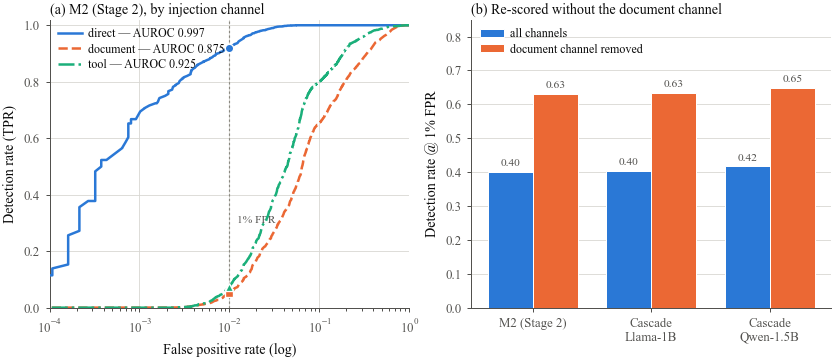

In [46]:
style(WIDTH)
fig, data = fig_channel_roc(D, WIDTH)
plt.show()

### What the figure says

M2's per-channel curves, and what happens if a channel is dropped:

| Channel | AUROC | DR at 1% FPR |
|---|---|---|
| direct | 0.997 | 0.920 |
| document | 0.875 | 0.051 |
| tool | 0.925 | 0.072 |

**A respectable AUROC and a near-zero detection rate coexist.** Tool injection scores
0.925 AUROC — the scores do carry real signal and do rank attacks above benign inputs
on average. But at the top of the ranking, where a 1% FPR cut falls, that signal is
gone: 7 attacks in 100. A threshold-free metric hides this completely. Any paper
reporting only AUROC on this data would look like it had solved the problem.

**Removing one corpus moves the headline by 23 points.**

| | all channels | document removed |
|---|---|---|
| Mistral-7B (M2) | 0.402 | 0.631 |
| Cascade (Qwen → M2) | 0.418 | 0.648 |
| Cascade (Llama → M2) | 0.403 | 0.633 |

That is not a result, and it is not a fix. It is a measure of how far a single
benchmark-composition choice can move a detection number. Report the mix alongside
the metric.

## 7. Cost frontier

Cascade behaviour as a function of the escalation rate `e`: detection saturates well before `e=1`, which is what makes routing viable at all. Break-even rates and the frozen operating points are marked.

In [47]:
def _frontier(D, key, step=0.005):
    s1_key, _ = CASCADES[key]
    s1_ps, s2, y = D["psafe"][s1_key], D["score"]["mistral7b"], D["y"]
    es, tprs, ths = [], [], []
    for th in np.arange(0.0, 1.0 + 1e-9, step):
        pt = _cascade_point(s1_ps, s2, y, float(th), FPR_TARGET)
        if not np.isfinite(pt["e2e_tpr"]):
            continue
        es.append(pt["escalation_rate"]); tprs.append(pt["e2e_tpr"]); ths.append(float(th))
    o = np.argsort(es)
    return np.asarray(es)[o], np.asarray(tprs)[o], np.asarray(ths)[o]


def fig_cost_frontier(D, width):
    fig, ax = panels(width, 2, 3.05, 2.9)
    a, b = ax[0], ax[1]
    m2_dr = dr_at(D["y"], D["score"]["mistral7b"])[0]
    data = {"stage2_only_dr_at_1pct_fpr": float(m2_dr), "cascades": {}}
    a.axhline(m2_dr, color=BLUE, lw=1.2, ls=(0, (5, 2)), zorder=2)
    a.text(0.02, m2_dr + 0.028, f"M2 on every input — DR {m2_dr:.3f}", color=BLUE,
           fontsize=mpl.rcParams["legend.fontsize"] - 0.3)
    for k in ("cascade_llama", "cascade_qwen"):
        _, col, ls, mk = ENT[k]; lab = elabel(k, width)
        e, tpr, _ = _frontier(D, k)
        a.plot(e, tpr, color=col, ls="-", lw=1.5, label=lab, zorder=3)
        summ = D["summaries"][k]["headline_cal_frozen"]["on_eval"]
        boot = D["summaries"][k]["headline_cal_frozen"]["bootstrap_eval"]["gap_cascade_minus_stage2"]
        a.plot([summ["escalation_rate"]], [summ["e2e_tpr"]], marker=mk, color=col, ms=6.5,
               mec=SURFACE, mew=0.9, ls="none", zorder=5)
        dx, dy = (-0.22, -0.075) if k == "cascade_qwen" else (0.09, -0.13)
        a.annotate(f"$e$ = {summ['escalation_rate']:.2f}", xy=(summ["escalation_rate"], summ["e2e_tpr"]),
                   xytext=(summ["escalation_rate"] + dx, summ["e2e_tpr"] + dy), color=col,
                   fontsize=mpl.rcParams["legend.fontsize"] - 0.3,
                   arrowprops=dict(arrowstyle="-", lw=0.6, color=col))
        data["cascades"][k] = {"operating_escalation": summ["escalation_rate"],
                               "operating_e2e_dr": summ["e2e_tpr"],
                               "gap_ci": [boot["lo"], boot["hi"]]}
    a.set_xlim(0, 1); a.set_ylim(0, 0.49)
    a.set_xlabel("Escalation rate $e$ (fraction sent to Stage 2)")
    a.set_ylabel("End-to-end detection @ 1% FPR")
    grid(a); plabel(a, "(a) Accuracy–cost frontier (frozen point marked)")
    a.legend(loc="lower right")

    k2 = D["latency"]["cascade_k1k2"]["llama3.2-1b"]["k2_ms"]
    e_grid = np.linspace(0, 1, 201)
    b.axhline(0.0, color=INK_MUTED, lw=0.7, ls=(0, (2, 2)), zorder=1)
    for k, mname in (("cascade_llama", "llama3.2-1b"), ("cascade_qwen", "qwen2.5-1.5b")):
        _, col, _, mk = ENT[k]; lab = elabel(k, width)
        blk = D["latency"]["cascade_k1k2"][mname]
        k1 = blk["k1_ms"]
        red = 1.0 - (k1 + e_grid * k2) / k2
        b.plot(e_grid, red * 100, color=col, ls="-", lw=1.5, label=lab, zorder=3)
        b.plot([blk["e"]], [blk["reduction_at_e"] * 100], marker=mk, color=col, ms=6.5,
               mec=SURFACE, mew=0.9, ls="none", zorder=5)
        tx, ty = (0.03, 10.0) if mname.startswith("qwen") else (0.63, 52.0)
        b.annotate(f"+{blk['reduction_at_e'] * 100:.1f}% at $e$ = {blk['e']:.2f}",
                   xy=(blk["e"], blk["reduction_at_e"] * 100), xytext=(tx, ty), color=col,
                   fontsize=mpl.rcParams["legend.fontsize"] - 0.3,
                   arrowprops=dict(arrowstyle="-", lw=0.6, color=col))
        b.plot([blk["breakeven_e"]], [0.0], marker="|", ms=9, mew=1.2, color=col, ls="none", zorder=5)
        b.annotate(f"break-even $e^*$ = {blk['breakeven_e']:.2f}", xy=(blk["breakeven_e"], 0.0),
                   xytext=(0.05, -19.0 if mname.startswith("qwen") else -31.0), color=col, ha="left",
                   va="center", fontsize=mpl.rcParams["legend.fontsize"] - 0.3,
                   arrowprops=dict(arrowstyle="-", lw=0.6, color=col))
        bf = D["latency_bf16"]["cascade_k1k2"][mname] if mname in D["latency_bf16"].get("cascade_k1k2", {}) else None
        data["cascades"].setdefault(k, {}).update({
            "k1_ms": k1, "k2_ms": k2, "breakeven_e": blk["breakeven_e"],
            "reduction_at_operating_e_pct": blk["reduction_at_e"] * 100,
            "usd_per_1m_cascade": blk["cascade_cost"]["usd_per_1m"],
            "usd_per_1m_stage2_only": blk["guard_cost"]["usd_per_1m"],
            "reduction_bf16_stage1_pct": (bf["reduction_at_e"] * 100 if bf else None)})
    b.set_xlim(0, 1); b.set_ylim(-40, 100)
    b.set_xlabel("Escalation rate $e$")
    b.set_ylabel("Inference-cost reduction (%)")
    grid(b); plabel(b, "(b) Measured cost reduction (A10G, batch = 1, 512 tok)")
    b.legend(loc="upper right")
    fig.tight_layout(pad=0.4)
    return fig, data

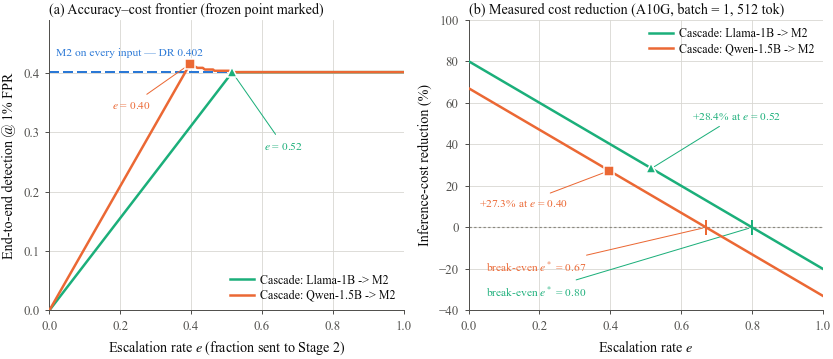

In [48]:
style(WIDTH)
fig, data = fig_cost_frontier(D, WIDTH)
plt.show()

### What the figure says

Running M2 on every input detects 0.4015 at 1% FPR. The cascades, at their frozen
operating points:

| | escalation *e* | end-to-end DR | gap vs M2-only (95% CI) | latency saved | $/1M inputs |
|---|---|---|---|---|---|
| M2 on every input | 1.000 | 0.4015 | — | — | 181.17 |
| Cascade (Qwen → M2) | 0.397 | 0.4152 | [+0.0040, +0.0225] | 27.3% | 131.76 |
| Cascade (Llama → M2) | 0.516 | 0.4012 | [−0.0007, +0.0056] | 28.4% | 129.77 |

**The Qwen cascade detects more than the model it routes to, for 27% less latency.**
The confidence interval excludes zero, so this is not noise. The Llama cascade's
interval contains zero: you get the saving, but detection is indistinguishable.

**Why a cascade can beat its own strong stage.** The 1% false-positive budget is
global. When Stage 1 auto-passes benign inputs, the pool of benign traffic reaching
Stage 2 shrinks, so the same global budget buys a *looser* threshold on what is left.
Stage 2 gets to be less cautious on the inputs it does see. That is the whole
mechanism, and section 11 shows it also has a cost: escalate too much and it reverses.

**Routing only pays below break-even.** Both models run on an escalated input, so
escalation is not free. Break-even is *e* = 0.670 for Qwen and *e* = 0.800 for Llama;
past that the cascade costs more than M2 alone. The operating points (0.397, 0.516)
sit comfortably under.

**Caveat.** The latency constants come from one hardware measurement — 179.5 ms for
Qwen, 108.9 ms for Llama, 543.5 ms for M2. Change the GPU or the batch size and
break-even moves with them. The detection numbers are hardware-independent; the cost
axis is not.

## 8. Calibration / reliability

Reliability diagrams before and after temperature scaling, with ECE. Relevant to why the frozen calibration threshold does not transfer.

In [49]:
def _reliability(ax, y, p, color, ls, marker, nbins=10):
    edges = np.linspace(0, 1, nbins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, nbins - 1)
    xs, ys = [], []
    for b in range(nbins):
        m = idx == b
        if m.sum() < 5:
            continue
        xs.append(float(p[m].mean())); ys.append(float(y[m].mean()))
    e = float(ece(y, p))
    ax.plot(xs, ys, color=color, ls=ls, marker=marker, ms=4.0, mec=SURFACE, mew=0.6, zorder=3)
    return e


def fig_calibration(D, width):
    fig, ax = panels(width, 3, 2.55, 2.5)
    data = {}
    for i, k in enumerate(("mistral7b", "qwen")):
        a = ax[i]
        a.plot([0, 1], [0, 1], color=INK_MUTED, lw=0.7, ls=(0, (2, 2)), zorder=1)
        a.text(0.58, 0.50, "perfect", color=INK_MUTED, rotation=38,
               fontsize=mpl.rcParams["legend.fontsize"] - 0.5)
        e_cal = _reliability(a, D["cal"]["y"], D["cal"][k]["score"], BLUE, "-", "o")
        e_ev = _reliability(a, D["y"], D["score"][k], ORANGE, "--", "s")
        a.set_xlim(0, 1); a.set_ylim(0, 1)
        a.set_xlabel("Predicted P(injection)"); a.set_ylabel("Observed attack fraction")
        grid(a); plabel(a, f"({'ab'[i]}) {SHORT[k]} reliability")
        ex, ey, eha, eva = (0.97, 0.04, "right", "bottom") if i == 0 else (0.03, 0.97, "left", "top")
        a.text(ex, ey, f"ECE {e_cal:.3f} \u2192 {e_ev:.3f}", transform=a.transAxes, ha=eha,
               va=eva, color=INK_2, fontsize=mpl.rcParams["legend.fontsize"])
        data[k] = {"ece_cal": e_cal, "ece_eval": e_ev}

    c = ax[2]
    y_c, s_c = D["cal"]["y"], D["cal"]["mistral7b"]["score"]
    y_e, s_e = D["y"], D["score"]["mistral7b"]
    _, thr, _ = dr_at(y_c, s_c)
    for yy, ss, col, ls in ((y_c, s_c, BLUE, "-"), (y_e, s_e, ORANGE, "--")):
        b = np.sort(ss[yy == 0])
        c.plot(np.maximum(b, 1e-8), 1.0 - np.arange(len(b)) / len(b), color=col, ls=ls, zorder=3)
    fpr_eval = float((s_e[y_e == 0] >= thr).mean())
    c.axvline(thr, color=INK_2, lw=0.8, ls=(0, (1, 1.5)), zorder=2)
    c.axhline(FPR_TARGET, color=INK_MUTED, lw=0.7, ls=(0, (2, 2)), zorder=1)
    c.plot([thr], [FPR_TARGET], marker="o", ms=4.5, color=BLUE, mec=SURFACE, mew=0.8, ls="none", zorder=5)
    c.plot([thr], [fpr_eval], marker="s", ms=4.5, color=ORANGE, mec=SURFACE, mew=0.8, ls="none", zorder=5)
    c.annotate(f"same threshold,\n{fpr_eval:.1%} FPR on eval", xy=(thr, fpr_eval), xytext=(3e-5, 0.28),
               color=ORANGE, fontsize=mpl.rcParams["legend.fontsize"] - 0.3, ha="left",
               arrowprops=dict(arrowstyle="-", lw=0.6, color=ORANGE))
    c.text(3e-1, FPR_TARGET * 1.4, "1% FPR target", color=INK_2, ha="right",
           fontsize=mpl.rcParams["legend.fontsize"] - 0.3)
    c.set_xscale("log"); c.set_yscale("log")
    c.set_xlim(1e-7, 1.0); c.set_ylim(1e-4, 1.3)
    c.set_xlabel("M2 injection score (log)"); c.set_ylabel("Fraction of benign above threshold")
    grid(c); plabel(c, "(c) Operating point does not transfer")
    data["threshold_transfer"] = {"cal_threshold_at_1pct_fpr": float(thr), "eval_fpr_at_that_threshold": fpr_eval}
    fig.tight_layout(pad=0.4)
    handles = [mpl.lines.Line2D([], [], color=BLUE, ls="-", marker="o", ms=4.0),
               mpl.lines.Line2D([], [], color=ORANGE, ls="--", marker="s", ms=4.0)]
    fig.legend(handles, ["calibration split (in-distribution)", "OOD eval"],
               loc="lower center" if width == "single" else "upper center",
               bbox_to_anchor=(0.5, -0.02) if width == "single" else (0.5, 1.10),
               ncol=2, columnspacing=1.6)
    return fig, data

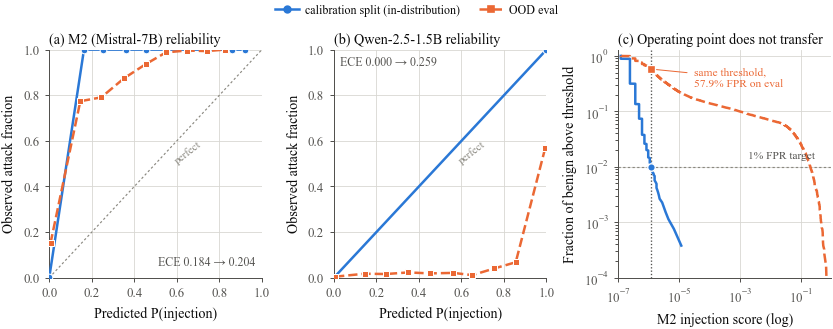

In [50]:
style(WIDTH)
fig, data = fig_calibration(D, WIDTH)
plt.show()

### What the figure says

Expected calibration error, measured on the split the temperature was fitted on and
then on the evaluation split:

| Model | ECE on calibration split | ECE on evaluation split |
|---|---|---|
| Mistral-7B (M2) | 0.184 | 0.204 |
| Qwen2.5-1.5B | 0.0003 | 0.259 |

**Qwen is almost perfectly calibrated where it was calibrated and badly miscalibrated
everywhere else.** The error grows by roughly 800×. Calibration is a property of the
distribution a model was calibrated on, not a property the model carries with it.

**The consequence is the number that governs this whole notebook.** The threshold that
produces a 1% false-positive rate on the calibration split produces **57.9%** on the
evaluation split. A guard shipped with that frozen threshold would flag more than half
of all benign traffic on day one.

Every detection rate reported here therefore assumes an oracle: someone already knew
the deployment traffic's benign score distribution and set the cut there. This is the
largest single gap between what is measured and what would be deployed, and no result
in this notebook closes it.

## 9. DataSentinel false positives against input length

The one detector here that cannot be placed on a false-positive budget at all: its error rate is a function of how long the benign input is.

In [51]:
def fig_datasentinel_length(D, width):
    y, pred, tl = D["y"], D["ds_pred"], D["tlen"]
    ben = y == 0
    q = np.quantile(tl[ben], [0.25, 0.5, 0.75])
    binidx = np.digitize(tl, q)
    labels = [f"Q1\n(<{int(q[0])})", f"Q2\n({int(q[0])}–{int(q[1])})",
              f"Q3\n({int(q[1])}–{int(q[2])})", f"Q4\n(>{int(q[2])})"]
    fprs, ns = [], []
    for b in range(4):
        m = ben & (binidx == b)
        fprs.append(float(pred[m].mean())); ns.append(int(m.sum()))
    fig, ax = panels(width, 1, 2.9, 3.0)
    a = ax[0]
    r = a.bar(np.arange(4), fprs, 0.58, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
    barlabel(a, r)
    overall = float(pred[ben].mean())
    a.axhline(overall, color=ORANGE, lw=1.2, ls=(0, (5, 2)), zorder=4)
    a.text(3.42, overall + 0.02, f"overall {overall:.2f}", color=ORANGE, ha="right",
           fontsize=mpl.rcParams["legend.fontsize"] - 0.3)
    a.axhline(FPR_TARGET, color=INK_MUTED, lw=0.7, ls=(0, (2, 2)), zorder=1)
    a.text(-0.42, FPR_TARGET + 0.02, "1% FPR budget", color=INK_2, ha="left",
           fontsize=mpl.rcParams["legend.fontsize"] - 0.3)
    a.set_xticks(np.arange(4)); a.set_xticklabels(labels)
    a.set_xlabel("Benign input length quartile (characters)")
    a.set_ylabel("DataSentinel-7B false positive rate")
    a.set_ylim(0, 1.05)
    grid(a, axis="y")
    fig.tight_layout(pad=0.4)
    return fig, {"fpr_by_benign_length_quartile": dict(zip(["q1", "q2", "q3", "q4"], fprs)),
                 "n_by_quartile": ns, "overall_benign_fpr": overall,
                 "quartile_edges_chars": [int(v) for v in q]}

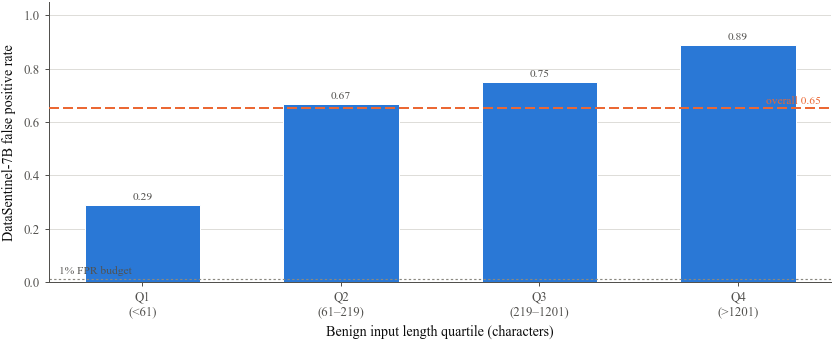

In [52]:
style(WIDTH)
fig, data = fig_datasentinel_length(D, WIDTH)
plt.show()

### What the figure says

DataSentinel's false-positive rate on benign inputs, split into quartiles by input
length:

| Quartile | Length (characters) | n | False-positive rate |
|---|---|---|---|
| Q1 | < 61 | 4,589 | 0.288 |
| Q2 | 61 – 219 | 4,723 | 0.668 |
| Q3 | 219 – 1,201 | 4,658 | 0.751 |
| Q4 | > 1,201 | 4,664 | 0.890 |
| overall | | 18,634 | 0.651 |

**The false-positive rate is not a constant — it tracks input length.** It climbs from
0.29 to 0.89 across the quartiles. On the longest quarter of benign inputs, nine in
ten are flagged as attacks.

**The mechanism is in the detection method.** DataSentinel decides by planting a canary
instruction and checking whether the model still obeys it. A long context makes the
model drop the canary for ordinary reasons that have nothing to do with an attack, so
length by itself reads as injection.

**This cannot be tuned away.** There is no score to threshold — the method emits a
decision — and the failure is conditional on a benign property of the input, so
lowering a cut would not help even if there were one. It is the one detector here
that cannot be placed on a 1% FPR budget at all.

## 10. Failure overlap (E13) — do the two stages miss the same attacks?

Three panels:

- **(a)** Stage-2 detection rate against Stage-1's routing score `p_safe`, attacks
  only. Were the router discarding catchable attacks, this curve would be flat.
- **(b)** Stage-2 injection-score distribution for escalated against auto-passed
  attacks. The auto-passed mass sits far below Stage 2's own threshold — it scores
  those inputs benign too.
- **(c)** Per channel: Stage 2 rescues 88.9% of Stage 1's misses on direct
  injection, but under 5% on document and tool, where Stage 1 in fact *outperforms*
  Stage 2.

Reads the Stage-1/Stage-2 logit files plus labels. No GPU.

### 10.1 Constants and helpers

`style()` is renamed `style_overlap()` — three scripts each defined a function by that name, and in one namespace they would overwrite each other.

In [53]:
ROOT = ROOT   # inherited from section 0.1
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"
BLUE, ORANGE, GREEN, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
FPR_TARGET, THETA_SAFE = 0.01, 0.005
S2 = "results/stage2/mistral-7b-v0.1/eval_logits.jsonl"
ARMS = [("Qwen2.5-1.5B", "results/stage1_prec/bf16/qwen2.5-1.5b/eval_logits.jsonl", BLUE),
        ("Llama3.2-1B",  "results/stage1_prec/bf16/llama3.2-1b/eval_logits.jsonl",  ORANGE)]
EDGES = [0, 1e-4, 1e-3, 5e-3, 2e-2, 1e-1, 1.0 + 1e-9]
LABELS = [r"$<10^{-4}$", r"$10^{-4}$–$10^{-3}$", r"$10^{-3}$–$5{\times}10^{-3}$",
          r"$5{\times}10^{-3}$–$0.02$", r"$0.02$–$0.1$", r"$>0.1$"]


def style_overlap():
    mpl.rcParams.update({
        "figure.dpi": 120, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "serif",
        "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif", "serif"],
        "mathtext.fontset": "stix", "font.size": 8.5, "axes.labelsize": 8.5,
        "axes.titlesize": 7.6, "xtick.labelsize": 7.7, "ytick.labelsize": 7.7,
        "legend.fontsize": 6.4, "legend.frameon": False,
        "axes.linewidth": 0.6, "axes.edgecolor": INK_2, "axes.labelcolor": INK,
        "text.color": INK, "xtick.color": INK_2, "ytick.color": INK_2,
        "xtick.major.width": 0.6, "ytick.major.width": 0.6,
        "axes.spines.top": False, "axes.spines.right": False,
    })


def p_safe(p): return np.asarray([json.loads(l)["p_safe"] for l in open(ROOT / p) if l.strip()], float)


def thr(score, y, target):
    b = score[y == 0]
    return max((t for t in np.unique(b) if (b >= t).mean() <= target),
               key=lambda t: (score[y == 1] >= t).mean())

### 10.2 Build the figure

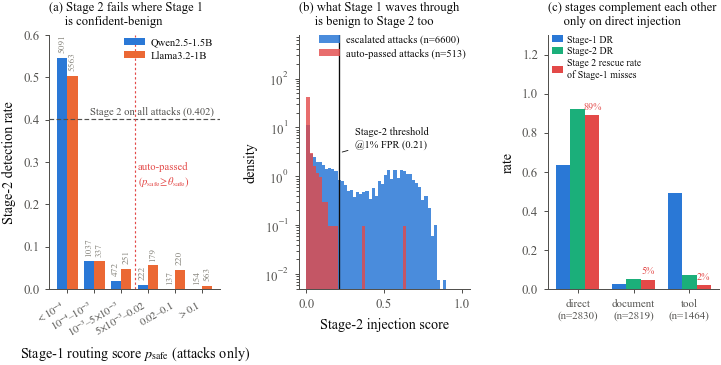

In [54]:
def plot_failure_overlap(eval_split="data/eval_proposal/eval.jsonl"):
    a = SimpleNamespace(eval_split=eval_split)
    style_overlap()

    y = np.array([int(json.loads(l)["label"]) for l in open(ROOT / a.eval_split) if l.strip()])
    s2 = 1.0 - p_safe(S2)
    t2 = thr(s2, y, FPR_TARGET)
    atk = y == 1
    f2 = s2 >= t2
    dr_all = f2[atk].mean()

    fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(7.2, 2.75))

    # ---- Panel A ----
    w = 0.38
    for j, (name, path, col) in enumerate(ARMS):
        v = p_safe(path)[atk]
        g = f2[atk]
        xs, hs, ns = [], [], []
        for i, (lo, hi) in enumerate(zip(EDGES[:-1], EDGES[1:])):
            m = (v >= lo) & (v < hi)
            xs.append(i + (j - 0.5) * w)
            hs.append(g[m].mean() if m.sum() else np.nan)
            ns.append(int(m.sum()))
        axA.bar(xs, hs, width=w, color=col, label=name, linewidth=0)
        for x, h, nn in zip(xs, hs, ns):
            if np.isnan(h):
                continue
            axA.text(x, h + 0.012, str(nn), ha="center", va="bottom",
                     fontsize=5.6, color=INK_MUTED, rotation=90)
    axA.axhline(dr_all, color=INK_2, lw=0.7, ls=(0, (4, 2)))
    axA.text(len(EDGES) - 1.55, dr_all + 0.012,
             f"Stage 2 on all attacks ({dr_all:.3f})",
             fontsize=6.4, color=INK_2, ha="right")
    axA.axvline(2.5, color=RED, lw=0.7, ls=(0, (2, 2)))
    axA.text(2.62, 0.30, "auto-passed\n" + r"($p_{\mathrm{safe}}\!\geq\!\theta_{\mathrm{safe}}$)",
             fontsize=6.4, color=RED, ha="left", va="top", linespacing=1.35)
    axA.set_xticks(range(len(LABELS)))
    axA.set_xticklabels(LABELS, rotation=30, ha="right", fontsize=6.2)
    axA.set_xlabel(r"Stage-1 routing score $p_{\mathrm{safe}}$ (attacks only)")
    axA.set_ylabel("Stage-2 detection rate")
    axA.set_ylim(0, 0.60)
    axA.legend(loc="upper right", bbox_to_anchor=(1.0, 1.02))
    axA.set_title("(a) Stage 2 fails where Stage 1\n     is confident-benign", loc="left")

    # ---- Panel B ----
    name, path, col = ARMS[0]
    v = p_safe(path)
    esc = atk & (v < THETA_SAFE)
    leak = atk & (v >= THETA_SAFE)
    bins = np.linspace(0, 1, 51)
    axB.hist(s2[esc], bins=bins, color=BLUE, alpha=0.85, linewidth=0,
             label=f"escalated attacks (n={esc.sum()})", density=True)
    axB.hist(s2[leak], bins=bins, color=RED, alpha=0.80, linewidth=0,
             label=f"auto-passed attacks (n={leak.sum()})", density=True)
    axB.set_yscale("log")
    axB.set_ylim(top=axB.get_ylim()[1] * 12)
    axB.axvline(t2, color=INK, lw=0.8)
    axB.annotate(f"Stage-2 threshold\n@1% FPR ({t2:.2f})",
                 xy=(t2, 3.0), xytext=(t2 + 0.10, 6.0),
                 fontsize=6.2, color=INK, va="center", ha="left", linespacing=1.3,
                 arrowprops=dict(arrowstyle="-", lw=0.5, color=INK))
    axB.set_xlabel("Stage-2 injection score")
    axB.set_ylabel("density")
    axB.legend(loc="upper right", bbox_to_anchor=(1.02, 1.03))
    axB.set_title("(b) what Stage 1 waves through\n     is benign to Stage 2 too", loc="left")

    # ---- Panel C: per-channel, is the strong stage complementary? ----
    ch = np.array([json.loads(l).get("channel") for l in open(ROOT / a.eval_split) if l.strip()], object)
    name, path, _ = ARMS[0]
    s1 = 1.0 - p_safe(path)
    t1 = thr(s1, y, FPR_TARGET)
    f1 = s1 >= t1
    chans = ["direct", "document", "tool"]
    xs = np.arange(len(chans))
    w3 = 0.26
    s1dr = [f1[atk & (ch == c)].mean() for c in chans]
    s2dr = [f2[atk & (ch == c)].mean() for c in chans]
    resc = [f2[atk & (ch == c) & ~f1].mean() for c in chans]
    axC.bar(xs - w3, s1dr, width=w3, color=BLUE, linewidth=0, label="Stage-1 DR")
    axC.bar(xs,      s2dr, width=w3, color=GREEN, linewidth=0, label="Stage-2 DR")
    axC.bar(xs + w3, resc, width=w3, color=RED, linewidth=0,
            label="Stage 2 rescue rate\nof Stage-1 misses")
    for x, v in zip(xs + w3, resc):
        axC.text(x, v + 0.02, f"{v:.0%}", ha="center", va="bottom", fontsize=6.0, color=RED)
    axC.set_xticks(xs)
    axC.set_xticklabels([f"{c}\n(n={int((atk & (ch == c)).sum())})" for c in chans], fontsize=6.6)
    axC.set_ylabel("rate")
    axC.set_ylim(0, 1.30)
    axC.legend(loc="upper left", bbox_to_anchor=(-0.02, 1.03), fontsize=5.9,
               labelspacing=0.2, handlelength=1.2, handletextpad=0.4)
    axC.set_title("(c) stages complement each other\n     only on direct injection", loc="left")

    fig.subplots_adjust(wspace=0.46)
    plt.show()
    return fig


_ = plot_failure_overlap()

### What the figure says

Both stages scored all 7,113 attacks in the evaluation split, each at its own 1%-FPR
threshold. Where they succeed and fail:

| | Stage 2 flags | Stage 2 misses |
|---|---|---|
| **Stage 1 flags** | 1,795 | 794 |
| **Stage 1 misses** | 1,061 | 3,463 |

**The two stages fail together more often than chance allows.** Stage 2 misses 59.8%
of attacks overall, but 76.5% of the attacks Stage 1 already missed — a lift of 1.28.
The miss sets correlate at φ = 0.450, and the two models' scores on attacks correlate
at Spearman ρ = 0.671. They are not independent detectors.

**The ceiling this imposes.** An oracle that picked whichever stage was right on each
input would reach 0.513. Every routing policy in this notebook is bounded by that, and
no amount of threshold tuning gets past it, because 3,463 attacks are invisible to both
models.

**Where Stage 2 rescues Stage 1, and where it does not.** Stage 2 recovers 23.5% of
Stage 1's misses overall, and that average hides everything:

| Channel | Stage 1 DR | Stage 2 DR | Both miss | Stage 2 rescues |
|---|---|---|---|---|
| direct | 0.636 | 0.920 | 4.0% | 88.9% |
| tool | 0.490 | 0.072 | 50.1% | 1.9% |
| document | 0.026 | 0.051 | 92.8% | 4.8% |

On tool injection the small Stage-1 model is the *better* detector (0.490 against
0.072), so escalating to Stage 2 there is a downgrade. The cascade's design assumption —
that the big model is a strict improvement — holds only on direct injection.

**Routing is not what loses the attacks.** At the shipped θ_safe = 0.005, Stage 1
auto-passes 513 attacks (7.2%). Stage 2 scores those at a detection rate of 0.0039,
against 0.4015 on attacks overall. Sending them to Stage 2 anyway would have recovered
almost none of them: the router is leaking attacks the strong model would also have
missed.

**What it means.** The two models share a blind spot because they learned the same
corpus surface cues. Stacking them cannot fix that, and neither can cascading,
ensembling or voting. The fix has to change what the models are trained on.

## 11. The routing threshold, as an operating plane

Every candidate $\theta_{\text{safe}}$ is a point in **(cost saved, attacks
caught)**. Up and to the right is better. The dashed line and open circle mark
M2-on-every-input, so points above the line detect more than the strong stage
alone.

Two things to read off it:

1. The arrow runs up-and-right for **both** Stage-1 options — the shipped
   threshold is dominated on both axes by the one a log-spaced grid selects on the
   calibration split (no test-set tuning).
2. Detection is **non-monotone** in $\theta_{\text{safe}}$. Past the peak,
   escalating more inputs buys *less* detection, because holding a fixed global
   FPR forces Stage 2's own threshold upward as more benign traffic reaches it.

Leak counts move opposite to detection and are not on this plane — see
`results/analysis/theta_safe_sweep.json`.

Reads only that JSON: no logits, no GPU.

### 11.1 Constants and helpers

In [55]:
ROOT = ROOT   # inherited from section 0.1
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"
BLUE, ORANGE, GREEN, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
SWEEP = "results/analysis/theta_safe_sweep.json"
COLOURS = {"Qwen-1.5B": BLUE, "Llama-1B": ORANGE}

# Which thresholds get a printed label, and where the label sits relative to its
# point, per arm. Labelling all 12 is unreadable; these span the range.
ANNOT = {
    "Qwen-1.5B": {0.0001: (2, 11), 0.005: (-19, 9), 0.316: (-2, 10)},
    "Llama-1B": {1e-05: (13, -3), 0.005: (-6, -11), 0.316: (-3, -11)},
}

# One Qwen point sits far below the plotted band; showing it would spend most of
# the vertical space on a region strictly worse than having no cascade at all.
# It is excluded from the axes and called out in text instead.
YLIM = (0.3985, 0.4375)


def style_sweep():
    mpl.rcParams.update({
        "figure.dpi": 120, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "serif",
        "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif", "serif"],
        "mathtext.fontset": "stix", "font.size": 8.5, "axes.labelsize": 8.5,
        "axes.titlesize": 8.5, "xtick.labelsize": 7.7, "ytick.labelsize": 7.7,
        "legend.fontsize": 7.0, "legend.frameon": False,
        "axes.linewidth": 0.6, "axes.edgecolor": INK_2, "axes.labelcolor": INK,
        "text.color": INK, "xtick.color": INK_2, "ytick.color": INK_2,
        "xtick.major.width": 0.6, "ytick.major.width": 0.6,
        "axes.spines.top": False, "axes.spines.right": False,
    })


def _mark(rows, key):
    for i, r in enumerate(rows):
        if key in (r.get("note") or ""):
            return i
    return None


def _fmt_theta(t: float) -> str:
    """5e-03 -> $5{\\times}10^{-3}$, 1e-04 -> $10^{-4}$."""
    e = int(np.floor(np.log10(t)))
    m = t / 10 ** e
    if abs(m - 1.0) < 0.02:
        return rf"$10^{{{e}}}$"
    return rf"${m:.2f}".rstrip("0").rstrip(".") + rf"{{\times}}10^{{{e}}}$"

### 11.2 Build the figure

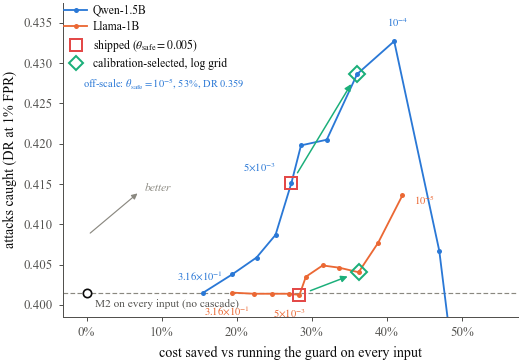

In [56]:
def plot_theta_sweep(sweep=SWEEP):
    a = SimpleNamespace(sweep=sweep)
    style_sweep()

    D = json.loads((ROOT / a.sweep).read_text())
    s2_only, frozen = D["stage2_only_dr"], D["frozen_theta_safe"]

    fig, ax = plt.subplots(figsize=(4.9, 3.4))

    # "no cascade" reference: pay the guard on every input, save nothing.
    ax.axhline(s2_only, color=INK_MUTED, lw=0.7, ls=(0, (4, 2)), zorder=1)
    ax.plot([0.0], [s2_only], "o", ms=5.0, mfc="white", mec=INK, mew=1.0, zorder=6)
    ax.annotate("M2 on every input (no cascade)", xy=(0.0, s2_only),
                xytext=(0.011, s2_only - 0.0008), fontsize=6.8, color=INK_2,
                va="top", ha="left")

    for name, arm in D["sweep"].items():
        col = COLOURS.get(name, INK_2)
        # theta_safe = 1 escalates everything and costs more than the guard alone
        # (both stages run); it is off-plane and excluded.
        rows = [r for r in arm["rows"] if r["theta_safe"] < 1.0]
        th = np.array([r["theta_safe"] for r in rows])
        dr = np.array([r["e2e_dr"] for r in rows])
        lat = np.array([r["latency_reduction"] for r in rows])
        i_cal, i_frz = _mark(rows, "CAL-SELECTED"), _mark(rows, "FROZEN")

        ax.plot(lat, dr, "-", color=col, lw=1.1, marker="o", ms=3.0,
                mfc=col, mec="none", label=name, zorder=3)

        for t, (dx, dy) in ANNOT.get(name, {}).items():
            k = int(np.argmin(np.abs(th - t)))
            ax.annotate(_fmt_theta(th[k]), xy=(lat[k], dr[k]), textcoords="offset points",
                        xytext=(dx, dy), fontsize=6.3, color=col, ha="center",
                        va="center", zorder=4)

        if i_frz is not None:
            ax.plot(lat[i_frz], dr[i_frz], "s", ms=7.5, mfc="none", mec=RED,
                    mew=1.2, zorder=7)
        if i_cal is not None:
            ax.plot(lat[i_cal], dr[i_cal], "D", ms=6.6, mfc="none", mec=GREEN,
                    mew=1.2, zorder=7)
        if i_frz is not None and i_cal is not None:
            ax.annotate("", xy=(lat[i_cal], dr[i_cal]), xytext=(lat[i_frz], dr[i_frz]),
                        arrowprops=dict(arrowstyle="-|>", lw=0.9, color=GREEN,
                                        shrinkA=7.0, shrinkB=7.0, mutation_scale=8),
                        zorder=5)

    ax.set_xlabel("cost saved vs running the guard on every input")
    ax.set_ylabel("attacks caught (DR at 1% FPR)")
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlim(-0.032, 0.575)
    ax.set_ylim(*YLIM)

    # name the excluded point rather than silently dropping it
    off = [(n, r) for n, arm in D["sweep"].items() for r in arm["rows"]
           if r["theta_safe"] < 1.0 and r["e2e_dr"] < YLIM[0]]
    for k, (n, r) in enumerate(off):
        ax.annotate(rf"off-scale: $\theta_{{\mathrm{{safe}}}}={_fmt_theta(r['theta_safe'])[1:-1]}$, "
                    rf"{r['latency_reduction']:.0%}, DR {r['e2e_dr']:.3f}",
                    xy=(0.045, 0.72 - 0.05 * k), xycoords="axes fraction",
                    fontsize=6.3, color=COLOURS.get(n, INK_2), ha="left", va="bottom")

    # direction-of-good, so the plane reads without the caption
    ax.annotate("", xy=(0.170, 0.40), xytext=(0.055, 0.26), xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", lw=0.7, color=INK_MUTED,
                                mutation_scale=7))
    ax.annotate("better", xy=(0.180, 0.410), xycoords="axes fraction", fontsize=6.8,
                color=INK_MUTED, ha="left", va="center", style="italic")

    handles, labels = ax.get_legend_handles_labels()
    handles += [plt.Line2D([], [], ls="none", marker="s", ms=7.0, mfc="none", mec=RED,
                           mew=1.2, label=rf"shipped ($\theta_{{\mathrm{{safe}}}}={frozen:g}$)"),
                plt.Line2D([], [], ls="none", marker="D", ms=6.2, mfc="none", mec=GREEN,
                           mew=1.2, label="calibration-selected, log grid")]
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(-0.015, 1.02),
              labelspacing=0.35, handletextpad=0.5)

    plt.show()
    return fig


_ = plot_theta_sweep()

### What the figure says

Each dot is one candidate routing threshold. Higher is more attacks caught; further
right is more cost saved. The shipped threshold and the one a log-spaced grid picks on
the calibration split:

| Stage 1 | θ_safe | escalation *e* | end-to-end DR | attacks leaked | latency saved |
|---|---|---|---|---|---|
| Qwen | 0.005 *(shipped)* | 0.397 | 0.415 | 460 | 27.3% |
| Qwen | 0.000316 *(re-selected)* | 0.309 | 0.429 | 1,492 | 36.0% |
| Qwen | 0.0001 *(peak DR)* | 0.260 | 0.433 | 2,133 | 41.0% |
| Llama | 0.005 *(shipped)* | 0.516 | 0.401 | 639 | 28.4% |
| Llama | 0.0001 *(re-selected)* | 0.437 | 0.404 | 1,160 | 36.2% |

**The shipped threshold is beaten on both axes at once.** For both Stage-1 options the
re-selected threshold catches more attacks *and* saves more latency. There is no
trade-off being made here and nothing was tuned on the test set — the re-selection uses
the same calibration split as the original.

**The reason is mundane.** The original search used a linear grid with a step of
5×10⁻³, so 0.005 was the smallest value it could ever return. The entire interesting
region lies below it.

**Detection is not monotone in θ_safe.** Qwen runs 0.359 at θ = 10⁻⁵, up to 0.433 at
θ = 10⁻⁴, back down to 0.402 at θ = 0.316. Both ends are bad for different reasons.
Below the peak, Stage 1 auto-passes real attacks — 4,179 of them at θ = 10⁻⁵. Above it,
so much benign traffic reaches Stage 2 that holding the global 1% budget forces Stage
2's own threshold upward, and it detects less on what it does see. This is the same
mechanism as section 7, run past its useful range.

**Escalating everything is the worst of both.** The θ_safe = 1 row detects 0.402 — the
same as M2 alone, as it must — at a latency reduction of **−33%**, because Stage 1 now
runs on every input and buys nothing.

**Leak counts move against detection and are not on this plane.** The re-selected Qwen
threshold catches more attacks end-to-end while auto-passing 1,492 rather than 460.
Those leaked attacks are overwhelmingly ones Stage 2 would also have missed (see
section 10), but if the deployment cares about *which* attacks reach the model rather
than how many are caught, that axis matters and this figure does not show it.

**Caveat.** Twelve points across five decades. The curve between them is interpolation,
and the peak's location is known only to within a factor of about three.

## Appendix — writing files instead of displaying

To regenerate the on-disk PDFs exactly as the paper uses them, run the scripts
rather than this notebook; they set the Agg backend and the 400 dpi PNG export:

```bash
PYTHONPATH=. python scripts/make_figures.py
PYTHONPATH=. python scripts/make_figure_failure_overlap.py
PYTHONPATH=. python scripts/make_figure_theta_sweep.py
```

To save a single figure from here instead, keep the returned `fig`:

```python
style(WIDTH)
fig, data = fig_roc(D, WIDTH)
fig.savefig("roc.pdf")
```